# 1 — Install

In [1]:
import subprocess, sys, os

FLAG = '/tmp/fre_installed.flag'
if not os.path.exists(FLAG):
    pkgs = [
        'numpy==1.24.4',
        'facenet-pytorch==2.5.3',
        'onnx>=1.14.0',
        'onnxruntime>=1.15.0',
        'seaborn>=0.12.0',
        'pyyaml>=6.0',
        'tensorboard>=2.13.0',
    ]
    for p in pkgs:
        print(f'Installing {p}...', end=' ', flush=True)
        r = subprocess.run([sys.executable,'-m','pip','install','-q',p],
                           capture_output=True, text=True)
        print('OK' if r.returncode==0 else f'GAGAL: {r.stderr[-100:]}')
    open(FLAG, 'w').close()
    print('\n== INSTALL SELESAI ==')
    print('Klik: Runtime -> Restart Runtime')
    print('Lalu jalankan mulai dari cell berikutnya')
else:
    print('Packages sudah terinstall.')

Installing numpy==1.24.4... GAGAL: e for output.

note: This error originates from a subprocess, and is likely not a problem with pip.

Installing facenet-pytorch==2.5.3... OK
Installing onnx>=1.14.0... OK
Installing onnxruntime>=1.15.0... OK
Installing seaborn>=0.12.0... OK
Installing pyyaml>=6.0... OK
Installing tensorboard>=2.13.0... OK

== INSTALL SELESAI ==
Klik: Runtime -> Restart Runtime
Lalu jalankan mulai dari cell berikutnya


# 2 — Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
BASE_DIR = '/content/drive/MyDrive/Projek/face_recognition_ewallet'

import sys, os
sys.path.insert(0, BASE_DIR)
os.chdir(BASE_DIR)

from src.utils import load_config, resolve_paths, set_seed, setup_logging, get_device

cfg    = load_config('config/config.yaml')
cfg    = resolve_paths(cfg, BASE_DIR)
set_seed(cfg['project']['seed'])
device = get_device()
setup_logging(cfg['paths']['logs'], 'evaluation')
print(f"Setup selesai | device={device}")

⚠️  GPU tidak ditemukan — pakai CPU (training akan lambat)
Setup selesai | device=cpu


# 3 — Load Model & Data Test

In [4]:
import pickle, torch
from src.models.backbone import FaceRecognitionModel
from src.data.dataset_loader import FaceDataset
from src.data.augmentation import get_val_transform
from torch.utils.data import DataLoader

with open(f"{cfg['paths']['results']}/split.pkl", 'rb') as f:
    meta = pickle.load(f)

test_d       = meta['test']
idx_to_class = meta['idx_to_class']
num_classes  = meta['num_classes']

val_tf      = get_val_transform(cfg)
test_ds     = FaceDataset(test_d[0], test_d[1], transform=val_tf)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False,
                         num_workers=cfg['data']['num_workers'], pin_memory=True)

ckpt  = torch.load(f"{cfg['paths']['checkpoints']}/best_model.pt", map_location=device)
model = FaceRecognitionModel(num_classes, cfg).to(device)
model.load_state_dict(ckpt['model_state'])
model.eval()

print(f"Model di-load dari epoch {ckpt['epoch']+1}")
print(f"Val accuracy saat training : {ckpt['val_acc']:.4f} ({ckpt['val_acc']*100:.2f}%)")
print(f"Test set                   : {len(test_d[0]):,} gambar, {num_classes} kelas")

[15:10:27][INFO] NumExpr defaulting to 2 threads.


  0%|          | 0.00/107M [00:00<?, ?B/s]

[15:10:37][INFO] FaceRecognitionModel | backbone=InceptionResnetV1 pretrained=vggface2 | head→105 kelas


Model di-load dari epoch 19
Val accuracy saat training : 0.9966 (99.66%)
Test set                   : 2,631 gambar, 105 kelas


# 4 — Evaluasi Lengkap

In [5]:
from src.evaluation.evaluator import Evaluator
import json

try:
    from src.training.trainer import History
    with open(f"{cfg['paths']['logs']}/history.json") as f:
        hdata = json.load(f)
    history = History()
    for k, v in hdata.items():
        setattr(history, k, v)
    print("History training di-load.")
except Exception:
    history = None
    print("History tidak ditemukan.")

evaluator = Evaluator(model, test_loader, cfg, device)
results   = evaluator.run(idx_to_class, history=history)

[15:10:45][INFO] Memulai evaluasi lengkap pada test set...


History training di-load.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/content/drive/MyDrive/Projek/face_recognition_ewallet/src/evaluation/evaluator.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.amp):
/usr/local/lib/python3.12/dist-packages/torch/cuda/amp/autocast_mode.py:54: UserWarning: CUDA is not available or torch_xla is imported. Disabling autocast.
  super().__init__(
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/content/drive/MyDrive/Projek/face_recognition_ewallet/src/evaluation/evaluator.py:66: FutureWarning: `torch.cuda.amp.autocast(arg


  HASIL EVALUASI — TEST SET
  🎯 top1_accuracy            : 0.9958
     top5_accuracy            : 0.9992
     macro_precision          : 0.9966
     macro_recall             : 0.9955
     macro_f1                 : 0.9959
     weighted_f1              : 0.9958
     roc_auc_macro            : 1.0000
     eer                      : 0.0002
     tar_at_far_0.1           : 1.0000
     tar_at_far_0.01          : 1.0000
     tar_at_far_0.001         : 1.0000

--- Classification Report (macro) ---
                        precision    recall  f1-score   support

          Adriana Lima       1.00      1.00      1.00        32
          Alex Lawther       1.00      1.00      1.00        23
    Alexandra Daddario       0.97      1.00      0.99        34
          Alvaro Morte       1.00      1.00      1.00        21
           Amanda Crew       1.00      1.00      1.00        17
          Andy Samberg       1.00      1.00      1.00        30
         Anne Hathaway       1.00      1.00      1.00  

# 5 — Tampilkan Semua Grafik

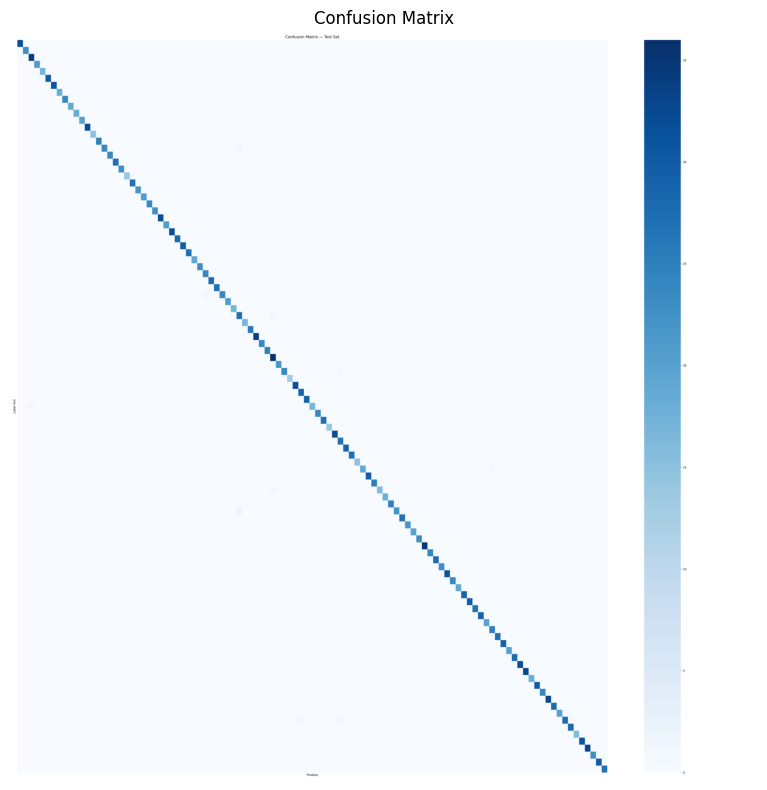

-> confusion_matrix.png


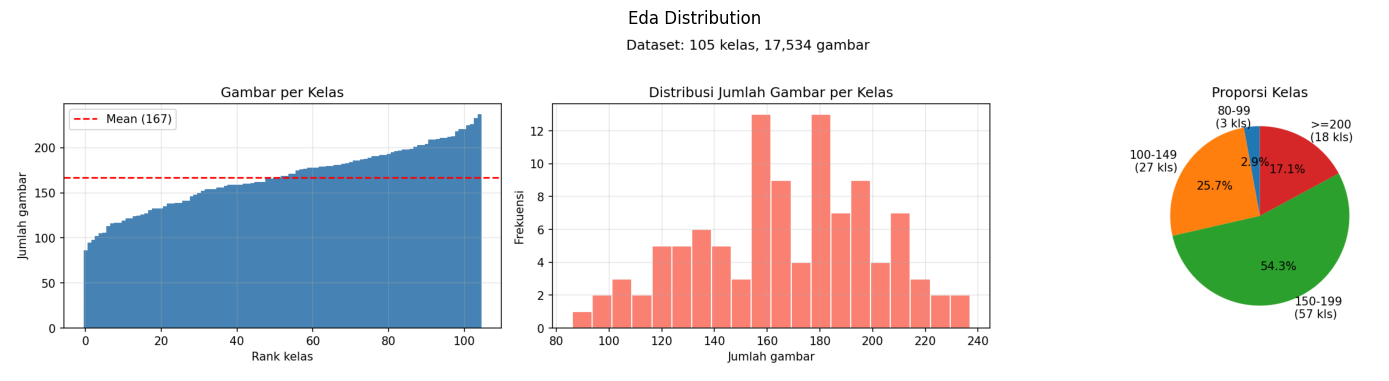

-> eda_distribution.png


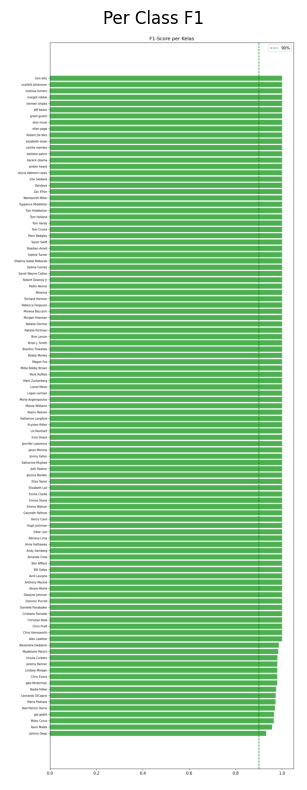

-> per_class_f1.png


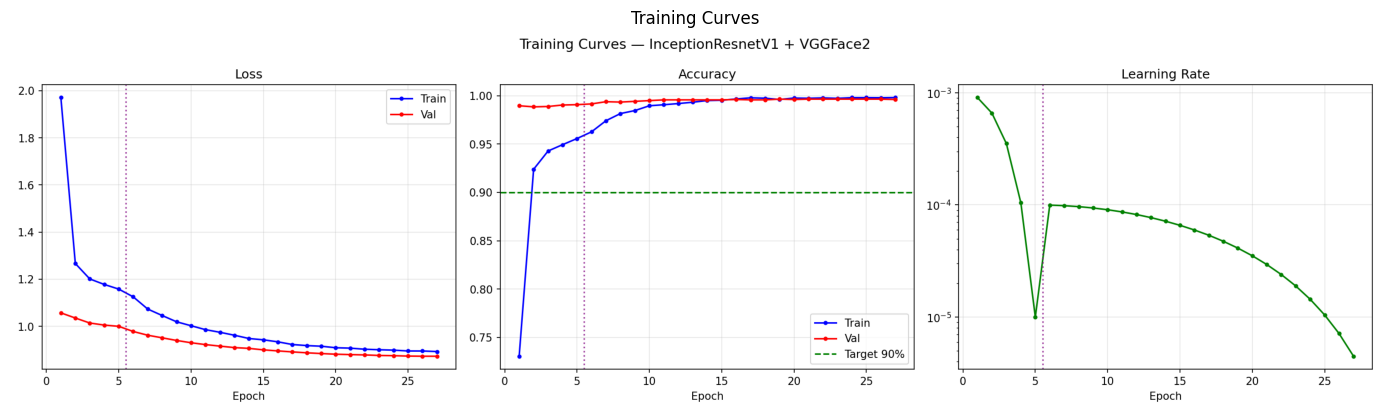

-> training_curves.png


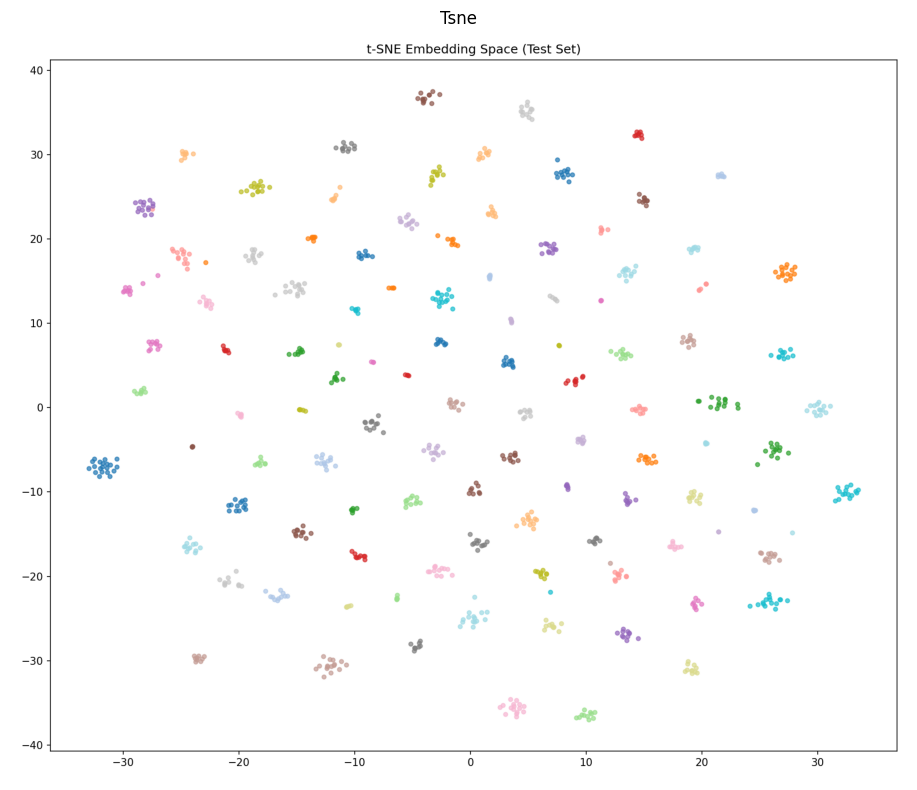

-> tsne.png


In [6]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

results_dir = Path(cfg['paths']['results'])
for fig_path in sorted(results_dir.glob('*.png')):
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(14, 8))
    plt.imshow(img); plt.axis('off')
    plt.title(fig_path.stem.replace('_', ' ').title())
    plt.tight_layout(); plt.show()
    print(f"-> {fig_path.name}")

# 6 — Cross-Validation (opsional)

In [9]:
RUN_CV = False   # <- ganti True untuk jalankan

if RUN_CV:
    from src.training.cross_validator import run_cv
    from src.data.augmentation import get_train_transform

    with open(f"{cfg['paths']['results']}/split.pkl", 'rb') as f:
        meta_cv = pickle.load(f)

    tr_d, val_d = meta_cv['train'], meta_cv['val']
    pool_X = tr_d[0] + val_d[0]
    pool_y = tr_d[1] + val_d[1]

    print(f"Menjalankan 5-Fold CV ...")
    cv_res = run_cv(pool_X, pool_y, meta_cv['num_classes'], cfg,
                    get_train_transform(cfg), get_val_transform(cfg), device)

    print(f"\nCV Result: {cv_res['mean_acc']:.4f} +/- {cv_res['std_acc']:.4f}")
    for i, acc in enumerate(cv_res['fold_accs']):
        print(f"  Fold {i+1}: {acc:.4f}")
else:
    print("CV dinonaktifkan (RUN_CV = False).")

CV dinonaktifkan (RUN_CV = False).
